# Module 5 — Day 1: From Logistic Regression to Neural Networks
## PHY 657, Spring 2026

---

### Where we are

In Module 4 we built a **linear classifier**: logistic regression draws a hyperplane in feature space and uses the sigmoid function to convert distance from the boundary into a probability.

We also saw that linear classifiers **fail** when the true decision boundary is curved (the ring problem, KNN comparison).

Today's question: **Can we keep the elegance of logistic regression but learn non-linear boundaries?**

The answer is yes — by stacking many logistic-regression-like units together. This is a neural network.

### Plan
1. Review: one neuron = logistic regression
2. Motivation: a physics problem where linearity fails
3. Building a network: layers, activations, forward pass
4. (Day 2) Training: loss functions, gradient descent, backpropagation

---
## Part 0: Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
RNG = np.random.default_rng(42)

---
## Part 1: One Neuron = Logistic Regression

Recall from Module 4, logistic regression computes:

$$z = \mathbf{w}^T \mathbf{x} + b$$
$$P(y=1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

This is exactly what a **single neuron** does:
1. Take a weighted sum of inputs (linear combination)
2. Pass it through an **activation function** (the sigmoid)
3. Output a number between 0 and 1

A single neuron *is* logistic regression. There is nothing more to it. If you understood Module 4, you already understand one neuron.

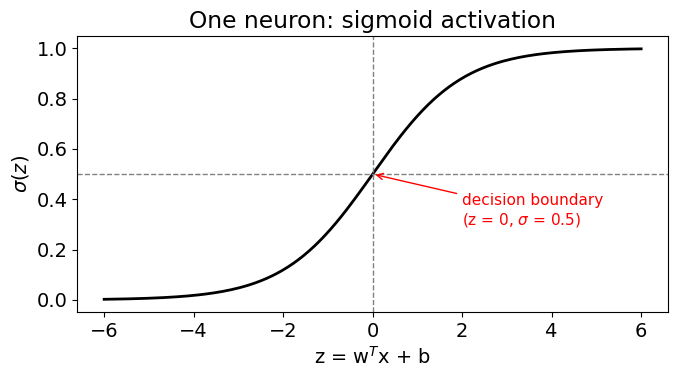

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

z = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid(z), 'k-', lw=2)
ax.axhline(0.5, color='gray', ls='--', lw=1)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('z = w$^T$x + b')
ax.set_ylabel('$\\sigma(z)$')
ax.set_title('One neuron: sigmoid activation')
ax.annotate('decision boundary\n(z = 0, $\\sigma$ = 0.5)', xy=(0, 0.5), xytext=(2, 0.3),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
plt.tight_layout()
plt.show()

---
## Part 2: Motivation — Phase Classification in the 2D Ising Model

We need a physics problem where a linear classifier fails. The 2D Ising model provides a beautiful example.

### The Ising model

The Ising model is one of the simplest models of a magnet. Consider an $L \times L$ grid of **spins**, each taking values $s_i \in \{+1, -1\}$ (think: tiny magnetic moments pointing up or down). Neighboring spins interact — they prefer to align. The total energy of a configuration is:

$$E = -J \sum_{\langle i,j \rangle} s_i s_j$$

where the sum runs over all nearest-neighbor pairs and $J > 0$ is the coupling strength. When neighbors agree ($s_i = s_j$), the energy decreases; when they disagree, it increases.

The competition between energy (which wants order) and entropy (which wants disorder) produces a **phase transition** at a critical temperature $T_c \approx 2.27\, J/k_B$:

- **Below $T_c$ (ordered / ferromagnetic):** Spins align, producing a net magnetization. The system spontaneously breaks symmetry — it can magnetize either all up or all down, both are equally valid.
- **Above $T_c$ (disordered / paramagnetic):** Thermal fluctuations randomize the spins. The net magnetization is approximately zero.

The **order parameter** for this transition is the absolute magnetization $|M| = |\sum_i s_i| / N$, which is large in the ordered phase and small in the disordered phase.

### The dataset: an ensemble of independent measurements

Imagine you have a magnetic sample in a cryostat. You heat it to some temperature $T$, wait for it to reach thermal equilibrium, then take a snapshot of the spin configuration. You reset and repeat — thousands of times, at many different temperatures. Each snapshot is one independent measurement.

Because each measurement is independent, the sample may magnetize up in one run and down in the next — both are equally probable equilibrium states below $T_c$. This is not an artifact; it reflects the $Z_2$ symmetry of the Ising Hamiltonian. (In contrast, if you slowly cooled a single sample once, it would pick one direction and stay there.)

We generate this dataset numerically using **Monte Carlo simulation** (the Metropolis algorithm), which produces spin configurations drawn from the thermal equilibrium distribution at each temperature. Each call to the Monte Carlo function is one run the experiment, equilibrate, take a snapshot.

### The classification task

Given a single spin configuration — just the grid of $+1$s and $-1$s — can a classifier determine which phase the system is in? You do not get to see the temperature; you only see the snapshot.

This is directly analogous to problems in experimental physics: given a detector readout, is this event signal or background? Given a pulse shape, is this a good event or a glitch? You see the data, not the underlying conditions that produced it.

### Why linear classifiers struggle

The order parameter is $|M|$ — the **absolute value** of the average spin. This is a non-linear function of the raw spins. An ordered configuration could be all up ($M \approx +1$) or all down ($M \approx -1$). A linear classifier computes $\mathbf{w}^T \mathbf{s}$, which is essentially the signed magnetization $M$. It cannot distinguish strongly negative $M$ (ordered, all down) from near-zero $M$ (disordered) without taking an absolute value — and absolute value is not a linear operation.

This is where neural networks come in: they can learn to compute non-linear features like $|M|$ from the raw data.

Let us generate some data and see this in action.

In [6]:
def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    if rng is None:
        rng = RNG
    spins = rng.choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = rng.integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins


def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=10000):
    T_low = RNG.uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = RNG.uniform(2.8, 4.0, size=n_samples_per_phase)
    configs, labels, temperatures = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps)
        configs.append(spins.flatten())
        labels.append(0)
        temperatures.append(T)
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps)
        configs.append(spins.flatten())
        labels.append(1)
        temperatures.append(T)
    X = np.array(configs, dtype=np.float64)
    y = np.array(labels)
    T_arr = np.array(temperatures)
    idx = RNG.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]


print('Generating Ising configurations (this may take a minute)...')
X_ising, y_ising, T_ising = generate_ising_dataset(L=10, n_samples_per_phase=400, n_mc_steps=8000)
print(f'Dataset: {X_ising.shape[0]} samples, {X_ising.shape[1]} features (10x10 grid)')
print(f'Ordered: {(y_ising==0).sum()}, Disordered: {(y_ising==1).sum()}')

# Save for student breakout notebook
np.savez('ising_data.npz', X=X_ising, y=y_ising, T=T_ising)

Generating Ising configurations (this may take a minute)...
Dataset: 800 samples, 100 features (10x10 grid)
Ordered: 400, Disordered: 400


### Visualize some configurations

Let us look at what the classifier will see. Each sample is a 10x10 grid of spins.

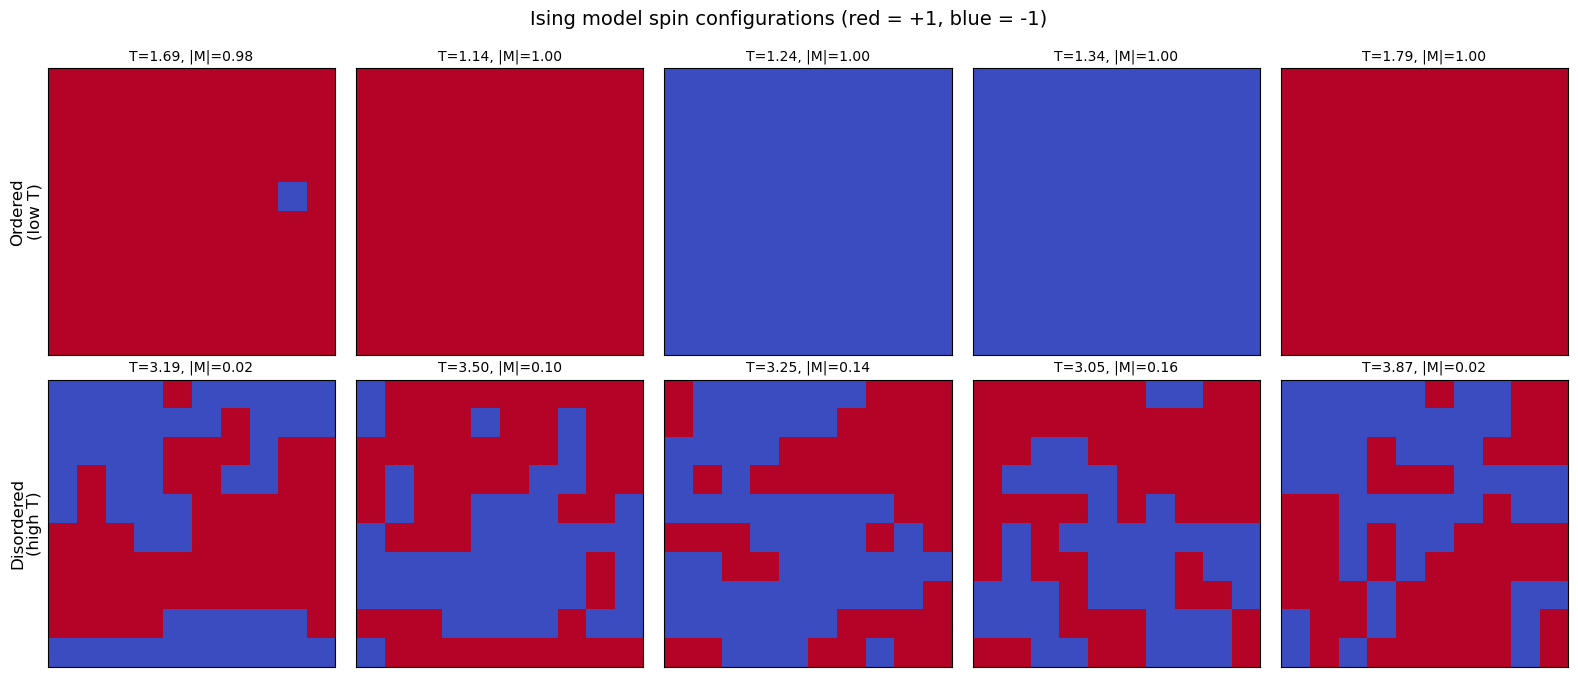

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

ordered_idx = np.where(y_ising == 0)[0][:5]
for i, idx in enumerate(ordered_idx):
    axes[0, i].imshow(X_ising[idx].reshape(10, 10), cmap='coolwarm', vmin=-1, vmax=1)
    M = np.abs(X_ising[idx].mean())
    axes[0, i].set_title(f'T={T_ising[idx]:.2f}, |M|={M:.2f}', fontsize=10)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
axes[0, 0].set_ylabel('Ordered\n(low T)', fontsize=12)

disordered_idx = np.where(y_ising == 1)[0][:5]
for i, idx in enumerate(disordered_idx):
    axes[1, i].imshow(X_ising[idx].reshape(10, 10), cmap='coolwarm', vmin=-1, vmax=1)
    M = np.abs(X_ising[idx].mean())
    axes[1, i].set_title(f'T={T_ising[idx]:.2f}, |M|={M:.2f}', fontsize=10)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
axes[1, 0].set_ylabel('Disordered\n(high T)', fontsize=12)

fig.suptitle('Ising model spin configurations (red = +1, blue = -1)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Breakout Exercise (~10 min)

**Open the breakout notebook and work with your partner.**

You have the Ising data loaded. Using what you learned in Module 4:

1. Split the data into train/test sets (70/30)
2. Fit a `LogisticRegression` classifier
3. Report the test accuracy
4. Compute the mean magnetization $M$ for each configuration and plot a histogram colored by phase

Discuss: Why does the linear classifier struggle? What does the histogram tell you?

---
### Breakout discussion and reveal

Let us see the results together.

In [9]:
X_tr_is, X_te_is, y_tr_is, y_te_is = train_test_split(
    X_ising, y_ising, test_size=0.3, random_state=0, stratify=y_ising
)

clf_lr_is = LogisticRegression(max_iter=1000)
clf_lr_is.fit(X_tr_is, y_tr_is)
acc_lr = clf_lr_is.score(X_te_is, y_te_is)
print(f'Logistic regression accuracy: {acc_lr:.2%}')

Logistic regression accuracy: 68.75%


Not terrible, but not great either. Why?

Logistic regression computes $\mathbf{w}^T \mathbf{s}$, which is essentially a weighted sum of spins — something like the signed magnetization $M$. Let us look at what is going on.

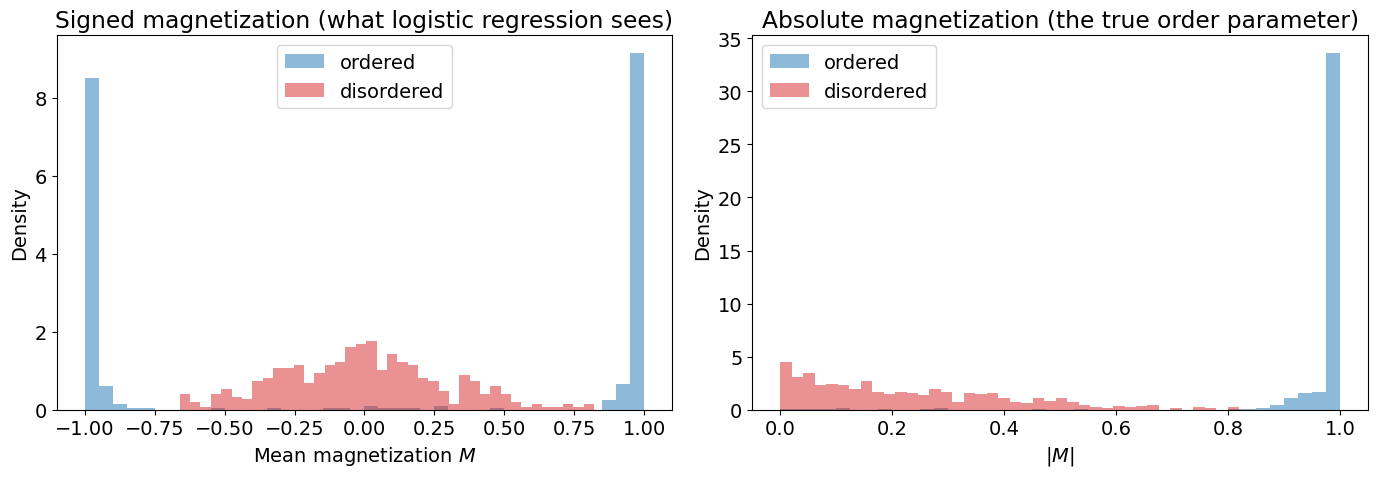

In [10]:
M_signed = X_ising.mean(axis=1)
M_abs = np.abs(X_ising.mean(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c, label, color in [(0, 'ordered', 'tab:blue'), (1, 'disordered', 'tab:red')]:
    sel = y_ising == c
    axes[0].hist(M_signed[sel], bins=40, alpha=0.5, color=color, label=label, density=True)
axes[0].set_xlabel('Mean magnetization $M$')
axes[0].set_ylabel('Density')
axes[0].set_title('Signed magnetization (what logistic regression sees)')
axes[0].legend()

for c, label, color in [(0, 'ordered', 'tab:blue'), (1, 'disordered', 'tab:red')]:
    sel = y_ising == c
    axes[1].hist(M_abs[sel], bins=40, alpha=0.5, color=color, label=label, density=True)
axes[1].set_xlabel('$|M|$')
axes[1].set_ylabel('Density')
axes[1].set_title('Absolute magnetization (the true order parameter)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Now we see the problem.** The left plot shows what the linear classifier effectively sees: the ordered phase (blue) is **bimodal** in $M$ — it can be strongly positive or strongly negative. The disordered phase (red) is peaked at zero. A single linear threshold cannot cleanly separate them.

The right plot shows $|M|$, which separates the phases cleanly. But computing $|M|$ from the raw spins requires a **non-linear** operation (the absolute value).

**This is exactly the problem we need neural networks to solve.** We need a model that can learn non-linear transformations of the input — like the absolute value — automatically.

Let us see how to build one.

---
## Part 3: Building a Neural Network

### From one neuron to many

A single neuron computes:
$$z = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

This is one linear operation followed by one non-linear activation. It can only learn linear boundaries.

**Key idea:** If we take the *outputs* of several neurons and feed them as *inputs* to another neuron, the second neuron operates on features that are already non-linear transformations of the original data. By stacking layers, we can represent increasingly complex functions.

### Architecture of a 2-layer network

For a network with one hidden layer of $H$ neurons:

<img src="neural_network_architecture.svg" width="700">

**Hidden layer** (layer 1): Each of $H$ neurons computes
$$h_j = \sigma\!\left(\sum_{i=1}^{D} w^{(1)}_{ji}\, x_i + b^{(1)}_j\right) \qquad j = 1, \ldots, H$$

**Output layer** (layer 2): A single neuron computes
$$\hat{y} = \sigma\!\left(\sum_{j=1}^{H} w^{(2)}_j\, h_j + b^{(2)}\right)$$

In matrix notation:
$$\mathbf{h} = \sigma\!\left(\mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}\right)$$
$$\hat{y} = \sigma\!\left(\mathbf{w}^{(2)T} \mathbf{h} + b^{(2)}\right)$$

where $\mathbf{W}^{(1)}$ is an $H \times D$ matrix and $\mathbf{w}^{(2)}$ is an $H$-dimensional vector.

### Activation functions

The sigmoid is not the only choice. Other common activation functions:

- **ReLU** (Rectified Linear Unit): $f(z) = \max(0, z)$ — most widely used in modern networks
- **tanh**: $f(z) = \tanh(z)$ — like sigmoid but centered at zero

The activation function is what makes the network non-linear. Without it, stacking linear layers just gives another linear function — you gain nothing.

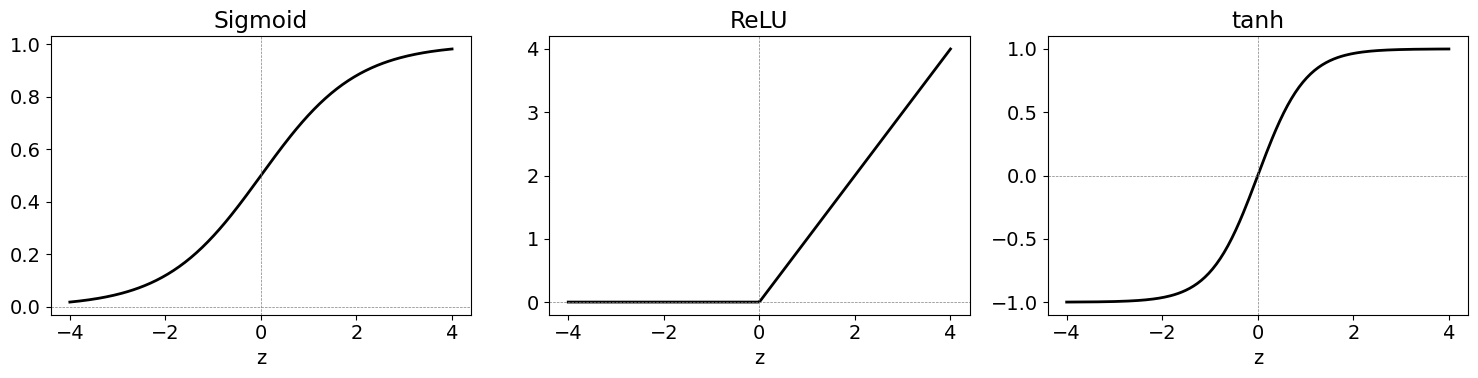

In [11]:
def relu(z):
    return np.maximum(0, z)

def tanh_func(z):
    return np.tanh(z)

z = np.linspace(-4, 4, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, func, name in zip(axes, [sigmoid, relu, tanh_func], ['Sigmoid', 'ReLU', 'tanh']):
    ax.plot(z, func(z), 'k-', lw=2)
    ax.axhline(0, color='gray', ls='--', lw=0.5)
    ax.axvline(0, color='gray', ls='--', lw=0.5)
    ax.set_title(name)
    ax.set_xlabel('z')
plt.tight_layout()
plt.show()

### The forward pass

Computing the output of the network given an input is called the **forward pass**. It is just a sequence of matrix multiplications and activation functions.

Let us implement it.

In [12]:
def forward(x, W1, b1, W2, b2):
    z1 = x @ W1.T + b1
    h = sigmoid(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

# Quick test with random weights
D = 4
H = 3
W1_test = RNG.standard_normal((H, D)) * 0.1
b1_test = np.zeros(H)
W2_test = RNG.standard_normal(H) * 0.1
b2_test = 0.0

x_test = RNG.standard_normal((5, D))
y_hat_test, h_test = forward(x_test, W1_test, b1_test, W2_test, b2_test)

print(f'Input shape:     {x_test.shape}')
print(f'Hidden shape:    {h_test.shape}')
print(f'Output shape:    {y_hat_test.shape}')
print(f'Predictions:     {y_hat_test.round(3)}')
print('\nWith random weights, outputs are near 0.5 -- the network has not learned anything yet.')

Input shape:     (5, 4)
Hidden shape:    (5, 3)
Output shape:    (5,)
Predictions:     [0.505 0.513 0.512 0.512 0.513]

With random weights, outputs are near 0.5 -- the network has not learned anything yet.


### What the hidden layer does geometrically

<img src="hidden_layer_feature_transform.svg" width="700">

The hidden layer **warps** the feature space so that classes that were interleaved in the original space become linearly separable in the learned representation. The output layer then draws a simple linear boundary in this new space — exactly what logistic regression does, but on transformed features.

---
## Summary

Today we established:

- A single neuron is identical to logistic regression
- The Ising model gives us a physics problem where linearity fails (because the order parameter $|M|$ is non-linear)
- Stacking neurons into layers allows the network to learn non-linear features
- The forward pass is just matrix multiplications and activation functions

**Next time:** How does the network *learn*? We will derive backpropagation, implement training from scratch, and watch the network discover the order parameter on its own.

---
## Remaining class time: work on HW 5

Use the remaining time to start on Problems 1 and 2 of the homework with your partner. Problem 1 (backprop by hand) asks you to do a complete forward and backward pass with specific numerical weights. Problem 2 asks you to modify the from-scratch numpy network code.

